In [1]:
import numpy as np
from sympy import symbols, Matrix, exp, I, simplify
import matplotlib.pyplot as plt

Coupler 50/50

\begin{equation*}
\mathbf{U} =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & j \\
j & 1
\end{pmatrix}
\end{equation*}

Phase shifter

\begin{equation*}
\mathbf{P}(\phi) =
\begin{pmatrix}
e^{j\phi} & 0 \\
0 & 1
\end{pmatrix}
%---------------
\quad \Rightarrow \quad
%---------------
P(\beta L) =
\begin{pmatrix}
e^{-j\beta L} & 0 \\
0 & 1
\end{pmatrix}
\end{equation*}

Funcion de transferencia del MZI

\begin{equation}
H = U \cdot P \cdot U
%-----------------------------------
= \frac{1}{2}
\begin{pmatrix}
e^{-j\beta L} - 1               & j\left( e^{-j\beta L} + 1 \right) \\
j\left(e^{-j\beta L} + 1 \right) & 1 - e^{-j\beta L}
\end{pmatrix}
%-----------------------------------
= \frac{1}{2}
\begin{pmatrix}
D - 1 & j(D + 1) \\
j(D + 1) & 1 - D
\end{pmatrix}
\end{equation}

\begin{equation}
D = e^{-j\beta L}
\end{equation}

Vector de entrada

\begin{equation*}
E_{\text{in}} =
\begin{pmatrix}
1 \\
0
\end{pmatrix}
\end{equation*}

\begin{equation*}
E_{\text{out}} = H \cdot E_{\text{in}}
\end{equation*}

Salidas

\begin{equation*}
H_{11} = \frac{1}{2}\left( 1 + e^{-j\beta L}\right) = \frac{1}{2}(1 + D)
\end{equation*}

\begin{equation*}
H_{21} = \frac{j}{2}\left( 1 - e^{-j\beta L}\right) = \frac{j}{2}(1 - D)
\end{equation*}

Salidas en magnitud

\begin{equation*}
\left|H_{11}\right|^2 = \frac{1}{2}\left(1 - \cos(\beta L)\right) = \sin^2\left(\frac{\beta L}{2}\right)
\end{equation*}

\begin{equation*}
\left|H_{21}\right|^2 = \frac{1}{2}\left(1 + \cos(\beta L)\right) = \cos^2\left(\frac{\beta L}{2}\right)
\end{equation*}

In [8]:
#---- parámetros----
alpha=0

n_eff0=1.6
n_g=1.6
wvl0=1.55e-6
wvlf=1.6e-6
wvli=1.5e-6

FSR = 25e-9          # 100 nm
L = wvl0**2 / (n_g * FSR)

wvl=np.linspace(1500e-9,1599e-9,2000)

phi=np.pi/2

print(L)

6.0062499999999996e-05


In [ ]:
# ---- constante de propagación ----
n_eff=n_eff0

# ---- propagación ----
beta = 2 * np.pi * n_eff / wvl


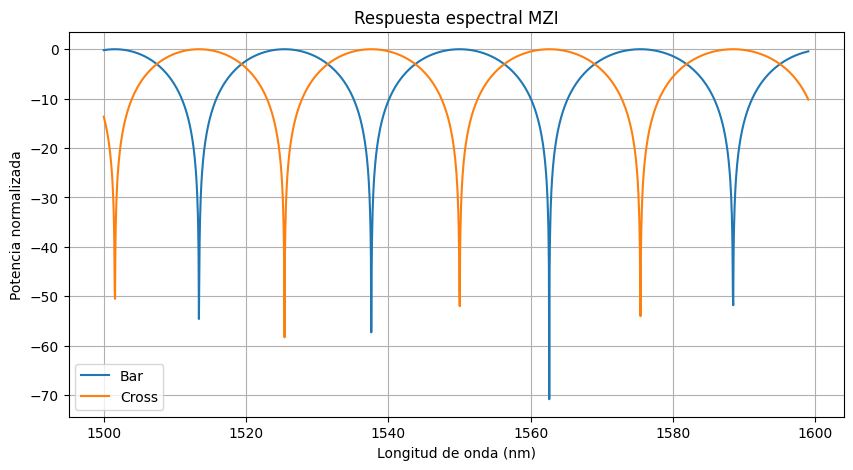

In [ ]:
D = np.exp(-1j * beta * L)

# ---- coeficientes ----
mzi_1_bar   = 0.5 * (1 + D)
mzi_1_cross = 0.5j * (1 - D)

# ---- potencias ----
P_bar = np.abs(mzi_1_bar)**2
P_cross = np.abs(mzi_1_cross)**2

# ---- evitar log(0) ----
eps = 1e-12
P_bar_dB = 10 * np.log10(P_bar + eps)
P_cross_dB = 10 * np.log10(P_cross + eps)


# ---- gráfica ----
plt.figure(figsize=(10,5))
plt.plot(wvl*1e9, P_bar_dB, label='Bar')
plt.plot(wvl*1e9, P_cross_dB, label='Cross')

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Potencia normalizada')
plt.title('Respuesta espectral MZI')
plt.legend()
plt.grid()

plt.show()

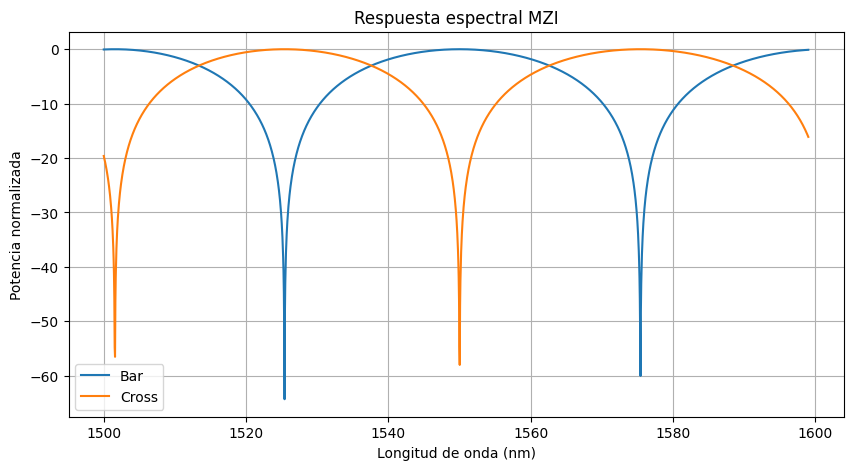

In [11]:
D = np.exp(-1j * beta * L/2)

# ---- coeficientes ----
mzi_1_bar   = 0.5 * (1 + D)
mzi_1_cross = 0.5j * (1 - D)

# ---- potencias ----
P_bar = np.abs(mzi_1_bar)**2
P_cross = np.abs(mzi_1_cross)**2

# ---- evitar log(0) ----
eps = 1e-12
P_bar_dB = 10 * np.log10(P_bar + eps)
P_cross_dB = 10 * np.log10(P_cross + eps)


# ---- gráfica ----
plt.figure(figsize=(10,5))
plt.plot(wvl*1e9, P_bar_dB, label='Bar')
plt.plot(wvl*1e9, P_cross_dB, label='Cross')

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Potencia normalizada')
plt.title('Respuesta espectral MZI')
plt.legend()
plt.grid()

plt.show()

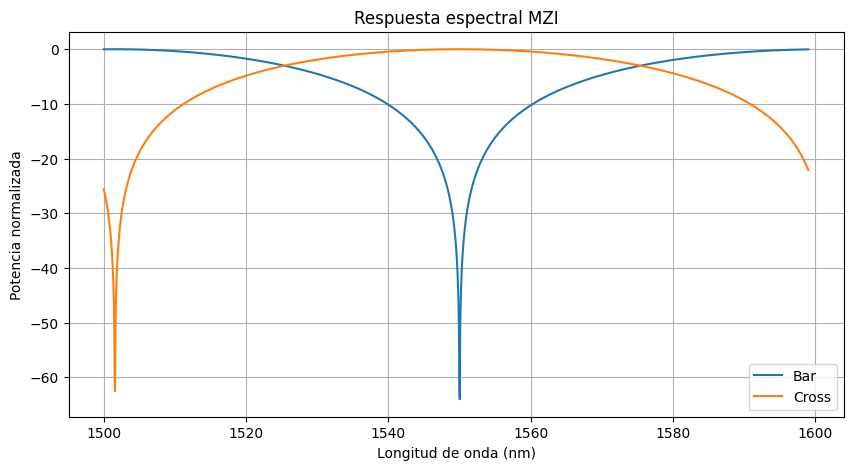

In [12]:
D = np.exp(-1j * beta * L/4)

# ---- coeficientes ----
mzi_1_bar   = 0.5 * (1 + D)
mzi_1_cross = 0.5j * (1 - D)

# ---- potencias ----
P_bar = np.abs(mzi_1_bar)**2
P_cross = np.abs(mzi_1_cross)**2

# ---- evitar log(0) ----
eps = 1e-12
P_bar_dB = 10 * np.log10(P_bar + eps)
P_cross_dB = 10 * np.log10(P_cross + eps)


# ---- gráfica ----
plt.figure(figsize=(10,5))
plt.plot(wvl*1e9, P_bar_dB, label='Bar')
plt.plot(wvl*1e9, P_cross_dB, label='Cross')

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Potencia normalizada')
plt.title('Respuesta espectral MZI')
plt.legend()
plt.grid()

plt.show()

Creo que ocurrirá un problema en el sentido de que no estoy generando los nodos que necesito para la construcción del filtro, quiero ver que ocurriría con un montaje en cascada



In [16]:
import numpy as np

def cascade_mzi(wvl, Ls, n_eff=1.6, Ein=(1.0, 0.0)):
    """
    wvl : array de longitudes de onda [m]
    Ls  : lista/array de longitudes de cada MZI [m]
    n_eff : índice efectivo
    Ein : (a0, b0) campo de entrada
    
    Returns:
        E_bar, E_cross, P_bar, P_cross (arrays vs wvl)
    """
    # estado inicial (arrays complejos del tamaño de wvl)
    a = np.full_like(wvl, Ein[0], dtype=complex)
    b = np.full_like(wvl, Ein[1], dtype=complex)

    beta = 2*np.pi*n_eff / wvl

    for L in Ls:
        D = np.exp(-1j * beta * L)

        a_next = 0.5 * ((1 + D)*a + 1j*(1 - D)*b)
        b_next = 0.5 * (1j*(1 - D)*a + (1 + D)*b)

        a, b = a_next, b_next

    E_bar, E_cross = a, b
    P_bar = np.abs(E_bar)**2
    P_cross = np.abs(E_cross)**2

    return E_bar, E_cross, P_bar, P_cross

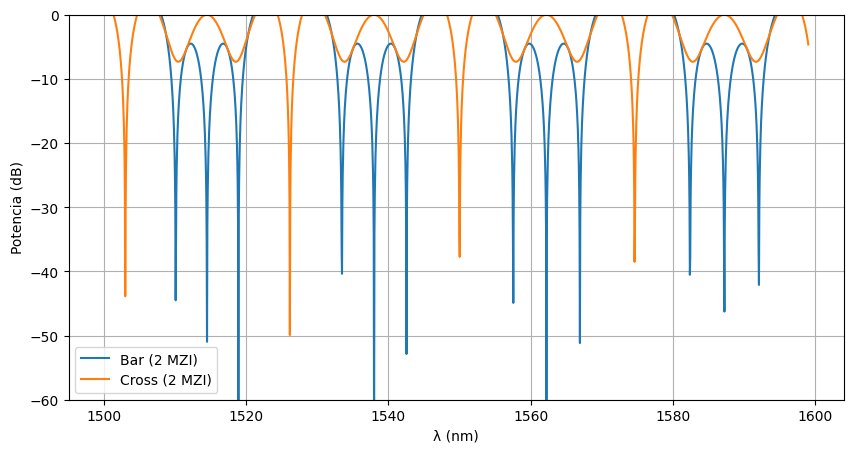

In [18]:
import matplotlib.pyplot as plt

wvl = np.linspace(1500e-9, 1599e-9, 2000)

L1 = 62e-6
L2 = 2*L1  
L3 = 2*L1 
E_bar, E_cross, P_bar, P_cross = cascade_mzi(
    wvl,
    Ls=[L1, L2, L3],
    n_eff=1.6,
    Ein=(1, 0)
)

# a dB
eps = 1e-12
P_bar_dB = 10*np.log10(P_bar + eps)
P_cross_dB = 10*np.log10(P_cross + eps)

plt.figure(figsize=(10,5))
plt.plot(wvl*1e9, P_bar_dB, label='Bar (2 MZI)')
plt.plot(wvl*1e9, P_cross_dB, label='Cross (2 MZI)')
plt.xlabel('λ (nm)')
plt.ylabel('Potencia (dB)')
plt.ylim(-60, 0)
plt.grid()
plt.legend()
plt.show()

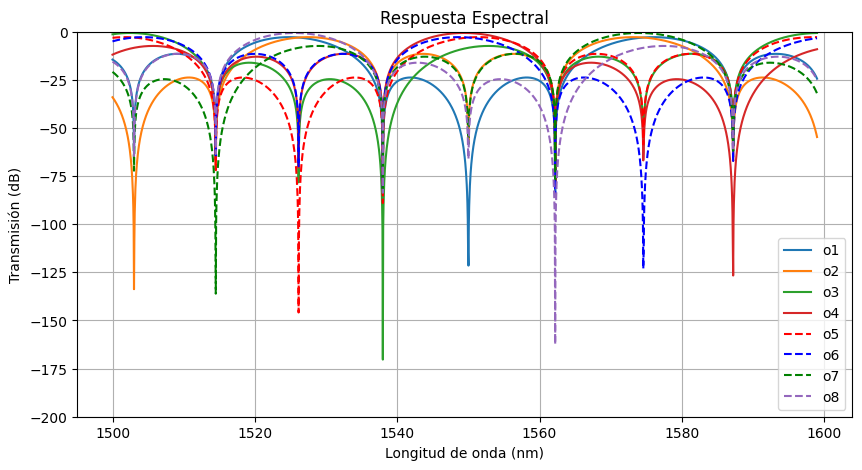

In [232]:
#n_eff = n_eff0+(n_eff0-n_g)*(wvl-wvl0)/wvl0
n_eff=n_eff0
beta=2*np.pi*n_eff/wvl
#D=np.exp(-1j*alpha*L)*np.exp(-1j*beta*L)
D=np.exp(-1j*beta*L)
D1=np.exp(-1j*beta*L/2)
D2=np.exp(-1j*beta*L/4)

PS1=np.exp(1j*0)
PS1_1=np.exp(1j*np.pi)

PS2=np.exp(1j*0)
PS3=np.exp(1j*(np.pi/4))
PS4=np.exp(1j*np.pi/2)
PS5=np.exp(1j*(3*np.pi/4))



Out1=1/8 * (D+1)*(D1*PS1-1)*(D2*PS2-1)
Out2=1/8 * (D+1)*(D1*PS1-1)*(1j*D2*PS2+1j)
Out3=1/8 * (D+1)*(1j*D1*PS1+1j)*(D2*PS3-1)
Out4=1/8 * (D+1)*(1j*D1*PS1+1j)*(1j*D2*PS3+1j)

Out5=1/8 * (D+1)*(D1*PS1_1-1)*(D2*PS4-1)
Out6=1/8 * (D+1)*(D1*PS1_1-1)*(1j*D2*PS4+1j)
Out7=1/8 * (D+1)*(1j*D1*PS1_1+1j)*(D2*PS5-1)
Out8=1/8 * (D+1)*(1j*D1*PS1_1+1j)*(1j*D2*PS5+1j)


plt.figure(figsize=(10, 5))
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out1)**2),label='o1')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out2)**2),label='o2')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out3)**2),label='o3')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out4)**2),label='o4')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out5)**2),linestyle='--',color='r',label='o5')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out6)**2),linestyle='--',color='b',label='o6')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out7)**2),linestyle='--',color='g',label='o7')
plt.plot(wvl * 1e9, 10 * np.log10(np.abs(Out8)**2),linestyle='--',label='o8')
plt.ylim(-200,0)
plt.legend()
plt.title("Respuesta Espectral")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Transmisión (dB)")
plt.grid(True)
plt.show()